In [2]:
import os
import json
import subprocess

In [3]:
from typing import Annotated, TypedDict, List
from langgraph.graph import StateGraph, START, END
from langchain_mcp_adapters.client import MultiServerMCPClient

In [4]:
from pydantic import BaseModel, Field
from typing import List

In [5]:
import asyncio
from langchain_groq import ChatGroq

In [6]:
from dotenv import load_dotenv
load_dotenv()

True

In [7]:
class LPIAgentResponse(BaseModel):
    """ Structured response for the LPI implementation advisor """
    answer: str = Field(description="The synthesized advice for the user's business scenario.")
    steps: List[str] = Field(description="A list of actionable implementation steps.")
    sources: List[str] = Field(description="Citations of the LPI tools and specific data points used (e.g., 'Tool: get_case_studies - Retail Case #1').")

In [8]:
llm = ChatGroq(api_key=os.getenv("GROQ_API_KEY"),model="llama-3.3-70b-versatile", temperature=0)
structured_llm = llm.with_structured_output(LPIAgentResponse)

In [9]:
_REPO_ROOT = r"C:\Users\Muskan Kirti\yash_lpi"
LPI_SERVER_CMD = ["node", os.path.join(_REPO_ROOT, "dist", "src", "index.js")]
LPI_SERVER_CWD = _REPO_ROOT

In [10]:
class AgentState(TypedDict):
    input: str
    tool_outputs: List[dict]      
    final_output: str

In [11]:
def call_lpi_tool_sync(tool_name: str, arguments: dict) -> str:
    """Synchronous bridge to the LPI MCP server using the org's JSON-RPC logic."""
    proc = subprocess.Popen(
        LPI_SERVER_CMD,
        stdin=subprocess.PIPE,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        cwd=LPI_SERVER_CWD,
        shell=True  # Added for better Windows command parsing
    )

    # Handshake logic from organization example
    init_req = {
        "jsonrpc": "2.0", "id": 0, "method": "initialize",
        "params": {
            "protocolVersion": "2024-11-05", "capabilities": {},
            "clientInfo": {"name": "langgraph-agent", "version": "1.0.0"},
        },
    }
    proc.stdin.write(json.dumps(init_req) + "\n")
    proc.stdin.flush()
    proc.stdout.readline() # Consume init response
    
    proc.stdin.write(json.dumps({"jsonrpc": "2.0", "method": "notifications/initialized"}) + "\n")
    proc.stdin.flush()

    # Tool calling logic from organization example
    request = {
        "jsonrpc": "2.0",
        "id": 1,
        "method": "tools/call",
        "params": {"name": tool_name, "arguments": arguments},
    }
    proc.stdin.write(json.dumps(request) + "\n")
    proc.stdin.flush()

    line = proc.stdout.readline()
    proc.terminate()
    
    if line:
        resp = json.loads(line)
        if "result" in resp and "content" in resp["result"]:
            return resp["result"]["content"][0].get("text", "No content")
    return f"[ERROR] Tool {tool_name} failed."


In [12]:
def choose_lpi_tools(query: str) -> List[str]:
    """Dynamically selects tools based on keywords in the query."""
    query = query.lower()
    tools = []

    if "how" in query or "implement" in query:
        tools.extend(["get_methodology_step", "get_insights"])

    if "example" in query or "case" in query:
        tools.append("get_case_studies")

    if any(word in query for word in ["what", "explain", "overview"]):
        tools.append("smile_overview")

    # Always include query_knowledge as a baseline tool for Level 3
    if "query_knowledge" not in tools:
        tools.append("query_knowledge")

    return list(set(tools))

In [20]:
def research_node(state: AgentState):
    print(f"--- RESEARCHING FOR: {state['input']} ---")
    
    selected_tools = choose_lpi_tools(state["input"])
    results = []
    
    for tool in selected_tools:
        print(f"Running tool: {tool}")
        try:
            data = call_lpi_tool_sync(tool, {"query": state["input"]})
            
            if "[ERROR]" in data:
                print(f"Warning: Tool {tool} returned an internal error.")
                results.append(f"Tool Used: {tool} | Status: Failed | Detail: {data}")
            else:
                results.append(f"Tool Used: {tool} | Data: {data[:1000]}")

        except Exception as e:
            error_msg = f"Exception occurred while calling {tool}: {str(e)}"
            print(f"CRITICAL ERROR: {error_msg}")
            results.append(f"Tool Used: {tool} | Status: Exception | Detail: {error_msg}")
    
    state["tool_outputs"] = results if results else ["No data retrieved due to tool failures."]
    return state

In [21]:
def summarize_node(state: AgentState):
    print("--- GENERATING FINAL ANSWER ---")
    
    prompt = f"""
    You are an expert LPI advisor. Answer the user question using ONLY the context provided.
    
    User Question: {state['input']}
    
    Context from LPI Tools:
    {state['tool_outputs']}
    
    Your response must include a clear answer, steps, and list the LPI tools used in 'sources'.
    """
    
    # Invoke structured LLM
    state["final_output"] = structured_llm.invoke(prompt)
    return state

In [15]:
workflow = StateGraph(AgentState)

workflow.add_node("research", research_node)
workflow.add_node("summarize", summarize_node)

workflow.add_edge(START, "research")
workflow.add_edge("research", "summarize")
workflow.add_edge("summarize", END)

wf = workflow.compile()

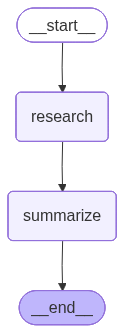

In [16]:
wf

In [17]:
import os
target_js = os.path.join(_REPO_ROOT, "dist", "src", "index.js")
print(f"Server script exists: {os.path.exists(target_js)}")

# Check if node is accessible
try:
    node_version = subprocess.check_output(["node", "-v"], shell=True).decode().strip()
    print(f"Node.js version: {node_version}")
except Exception as e:
    print(f"Node.js not found in PATH: {e}")

Server script exists: True
Node.js version: v24.15.0


In [24]:
user_query = "What are the core phases of the SMILE methodology?"
result = wf.invoke({"input": user_query})

--- RESEARCHING FOR: What are the core phases of the SMILE methodology? ---
Running tool: query_knowledge
Running tool: smile_overview
--- GENERATING FINAL ANSWER ---


In [25]:
result

{'input': 'What are the core phases of the SMILE methodology?',
 'tool_outputs': ['Tool Used: query_knowledge | Data: # Knowledge Results\n\n43 entries found (showing top 5):\n\n## SMILE Six-Phase Digital Twin Journey\n\nThe SMILE methodology defines six progressive phases for digital twin implementation: (1) Reality Emulation â€” creating a shared digital representation of the as-is reality, (2) Concurrent Engineering â€” virtual-first completion with emulation-based scenarios, (3) Collective Intelligence â€” invite to innovate, define scope, validate hypotheses, define the Minimal Viable Twin (MVT), (4) Contextual Intelligence â€” physical sensors, meet initial KPIs, ontology creation, remote enablement, (5) Continuous Intelligence â€” connected everything, command and control, real-time decisions, predictive analytics, root cause analysis, (6) Perpetual Wisdom â€” prescriptive maintenance, AI-driven prognostics, universal event pipeline, black swan identification, ecosystem enableme